# Bài toán 2 – Dự báo giá cổ phiếu DJIA bằng RNN / LSTM / GRU (Keras (TensorFlow))

**Dữ liệu:** *DJIA 30 Stock Time Series* (Kaggle) – tệp `all_stocks_2006-01-01_to_2018-01-01.csv` gồm OHLCV hằng ngày của 30 cổ phiếu, 2006–2017.

**Bài toán:** với một mã cổ phiếu, dùng `WINDOW` phiên gần nhất để dự đoán **lợi suất log của phiên kế tiếp**, rồi quy đổi thành **giá đóng cửa dự đoán**. So sánh `RNN`, `LSTM`, `GRU` với hai baseline (giá không đổi, drift).

**Vì sao dự báo lợi suất mà không phải giá thô?** Giá là chuỗi không dừng: tập kiểm thử (2016–2017) thường có giá cao hơn hẳn phạm vi của tập huấn luyện nên mô hình huấn luyện trên giá thô sẽ ngoại suy kém. Lợi suất là chuỗi gần dừng, và là đại lượng phản ánh đúng khả năng dự báo.

**Quy trình:** 1) Nạp và kiểm tra → 2) EDA → 3) Đặc trưng và cửa sổ trượt → 4) Baseline → 5) Huấn luyện 3 mô hình → 6) Đánh giá, trực quan hóa → 7) Phân tích đặc trưng → 8) Dự báo tương lai → 9) Kết luận.

> **Cảnh báo:** đây là bài tập học thuật. Kết quả không phải khuyến nghị đầu tư và không tính chi phí giao dịch.

## 0. Thư viện và cấu hình

In [1]:
import os, glob, math, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 100, "figure.figsize": (11, 4),
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "bold",
})
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
pd.set_option("display.max_columns", 30)

In [2]:
# ======================== CẤU HÌNH (có thể chỉnh) ========================
DATA_PATH   = "../data/all_stocks_2006-01-01_to_2018-01-01.csv"   # <-- đường dẫn tới tệp CSV đã tải về
TICKER      = "IBM"   # mã cổ phiếu cần phân tích (AAPL, MSFT, GE, JPM, ...)
WINDOW      = 60      # số phiên giao dịch lịch sử đưa vào RNN
HORIZON     = 5       # số phiên dự báo tương lai
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15

UNITS       = 64
DROPOUT     = 0.2
LR          = 1e-3
BATCH_SIZE  = 32
EPOCHS      = int(os.environ.get("NB_EPOCHS", 100))
PATIENCE    = 12
SEED        = 42

In [3]:
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__)
print("Thiết bị:", [d.name for d in tf.config.list_physical_devices()])

TensorFlow: 2.21.0 | Keras: 3.15.1
Thiết bị: ['/physical_device:CPU:0']


In [4]:
def find_data_file(path, pattern):
    """Trả về đường dẫn tệp dữ liệu. Nếu DATA_PATH không tồn tại thì tự tìm theo mẫu tên trong thư mục hiện tại."""
    if os.path.exists(path):
        return path
    found = glob.glob(pattern) + glob.glob(os.path.join("**", pattern), recursive=True)
    found = sorted(set(found), key=lambda p: ("large" not in p.lower(), len(p), p))
    if not found:
        raise FileNotFoundError(
            f"Không tìm thấy '{path}'. Hãy sửa biến DATA_PATH ở ô cấu hình thành đường dẫn tới tệp CSV đã tải về.")
    print(f"Không thấy '{path}', tự động dùng: {found[0]}")
    return found[0]

def acf(x, nlags):
    """Hàm tự tương quan (ACF) tính trực tiếp bằng numpy."""
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    d = np.dot(x, x)
    return np.array([np.dot(x[:len(x) - k], x[k:]) / d for k in range(nlags + 1)])

def plot_acf(ax, x, nlags, title):
    a = acf(x, nlags)
    conf = 1.96 / np.sqrt(len(x))
    ax.bar(range(nlags + 1), a, width=0.3, color="#2F5496")
    ax.axhline(conf, ls="--", c="r", lw=1); ax.axhline(-conf, ls="--", c="r", lw=1)
    ax.axhline(0, c="k", lw=0.8)
    ax.set_title(title); ax.set_xlabel("Độ trễ (lag)"); ax.set_ylabel("ACF")
    return a, conf

## 1. Nạp dữ liệu và kiểm tra chất lượng

In [5]:
DATA_PATH = find_data_file(DATA_PATH, "all_stocks*.csv")
raw = pd.read_csv(DATA_PATH)
raw.columns = raw.columns.str.strip()
need = ["Date", "Open", "High", "Low", "Close", "Volume", "Name"]
assert all(c in raw.columns for c in need), f"Thiếu cột. Cần {need}, hiện có {list(raw.columns)}"
raw["Date"] = pd.to_datetime(raw["Date"], errors="coerce")
raw = raw.dropna(subset=["Date"]).sort_values(["Name", "Date"]).reset_index(drop=True)

print(f"Tổng số dòng: {len(raw):,} | Số mã cổ phiếu: {raw['Name'].nunique()}")
print(f"Khoảng thời gian: {raw['Date'].min().date()} -> {raw['Date'].max().date()}")
display(raw.head())
na = raw[need].isna().sum(); print("Giá trị thiếu theo cột:"); display(na.to_frame("Số ô thiếu").T)
print("Dòng trùng (Name, Date):", raw.duplicated(["Name", "Date"]).sum())

Tổng số dòng: 93,612 | Số mã cổ phiếu: 31
Khoảng thời gian: 2006-01-03 -> 2017-12-29


,Date,Open,High,Low,Close,Volume,Name
0,2006-01-03,39.6900,41.2200,38.7900,40.9100,24232729,AABA
1,2006-01-04,41.2200,41.9000,40.7700,40.9700,20553479,AABA
2,2006-01-05,40.9300,41.7300,40.8500,41.5300,12829610,AABA
3,2006-01-06,42.8800,43.5700,42.8000,43.2100,29422828,AABA
4,2006-01-09,43.1000,43.6600,42.8200,43.4200,16268338,AABA


Giá trị thiếu theo cột:


,Date,Open,High,Low,Close,Volume,Name
Số ô thiếu,0,25,10,20,0,0,0


Dòng trùng (Name, Date): 0


## 2. Phân tích khám phá (EDA)
### 2.1 Tổng quan 30 mã và chọn mã phân tích

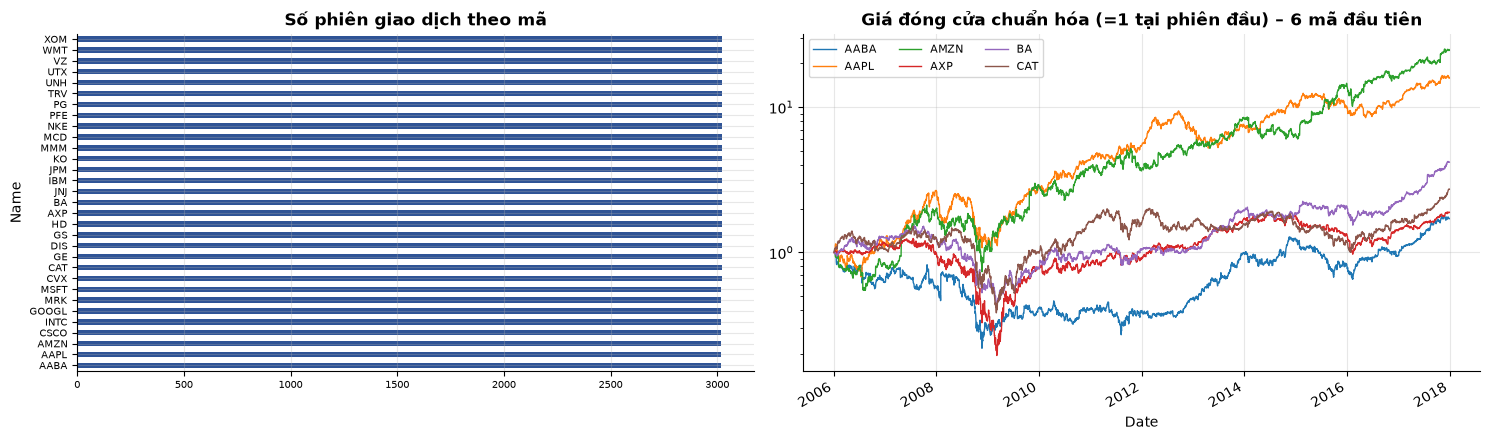

Các mã có ít phiên nhất (niêm yết muộn hoặc thiếu dữ liệu): {'AABA': 3019, 'AAPL': 3019, 'AMZN': 3019}

>>> Phân tích chi tiết mã IBM: 3020 phiên, 2006-01-03 -> 2017-12-29


,count,mean,std,min,25%,50%,75%,max
Open,"3,020.0000",145.5153,37.5487,72.7400,116.4075,149.6050,178.4375,215.3800
High,"3,020.0000",146.6817,37.6134,73.9400,117.7650,150.3300,179.7625,215.9000
Low,"3,020.0000",144.4714,37.4714,69.5000,115.5000,148.4250,177.3200,214.3000
Close,"3,020.0000",145.6173,37.5294,71.7400,116.5250,149.3150,178.6850,215.8000
Volume,"3,020.0000","5,773,300.6225","3,192,830.5401","254,256.0000","3,622,681.2500","4,928,851.5000","6,965,014.0000","30,774,276.0000"


In [6]:
cnt = raw.groupby("Name").size().sort_values()
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
cnt.plot.barh(ax=axes[0], color="#2F5496", fontsize=7); axes[0].set_title("Số phiên giao dịch theo mã")
tick_show = list(raw["Name"].unique()[:6])
for t in tick_show:
    s = raw[raw["Name"] == t].set_index("Date")["Close"].dropna()
    (s / s.iloc[0]).plot(ax=axes[1], lw=1, label=t)
axes[1].set_title("Giá đóng cửa chuẩn hóa (=1 tại phiên đầu) – 6 mã đầu tiên"); axes[1].legend(ncol=3, fontsize=8)
axes[1].set_yscale("log"); plt.tight_layout(); plt.show()
print("Các mã có ít phiên nhất (niêm yết muộn hoặc thiếu dữ liệu):", cnt.head(3).to_dict())

if TICKER not in raw["Name"].unique():
    print(f"Không có mã '{TICKER}', chuyển sang mã đầu tiên: {raw['Name'].iloc[0]}")
    TICKER = raw["Name"].iloc[0]
df_t = raw[raw["Name"] == TICKER].set_index("Date")[["Open", "High", "Low", "Close", "Volume"]].sort_index()
df_t = df_t[~df_t.index.duplicated()].ffill()
print(f"\n>>> Phân tích chi tiết mã {TICKER}: {len(df_t)} phiên, {df_t.index.min().date()} -> {df_t.index.max().date()}")
display(df_t.describe().T)

### 2.2 Đặc điểm chuỗi giá của mã được chọn
Giá, đường trung bình động, khối lượng, phân phối lợi suất, biến động, tự tương quan, tương quan giữa các cột, lợi suất theo năm và drawdown.

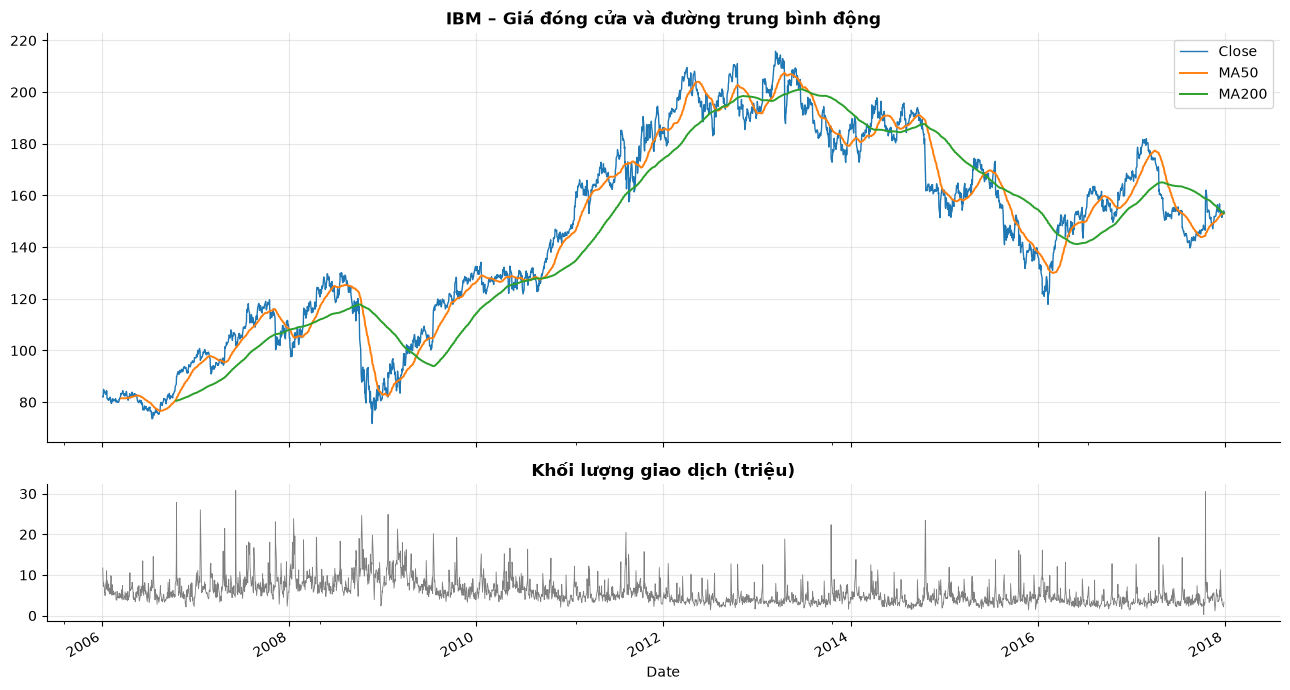

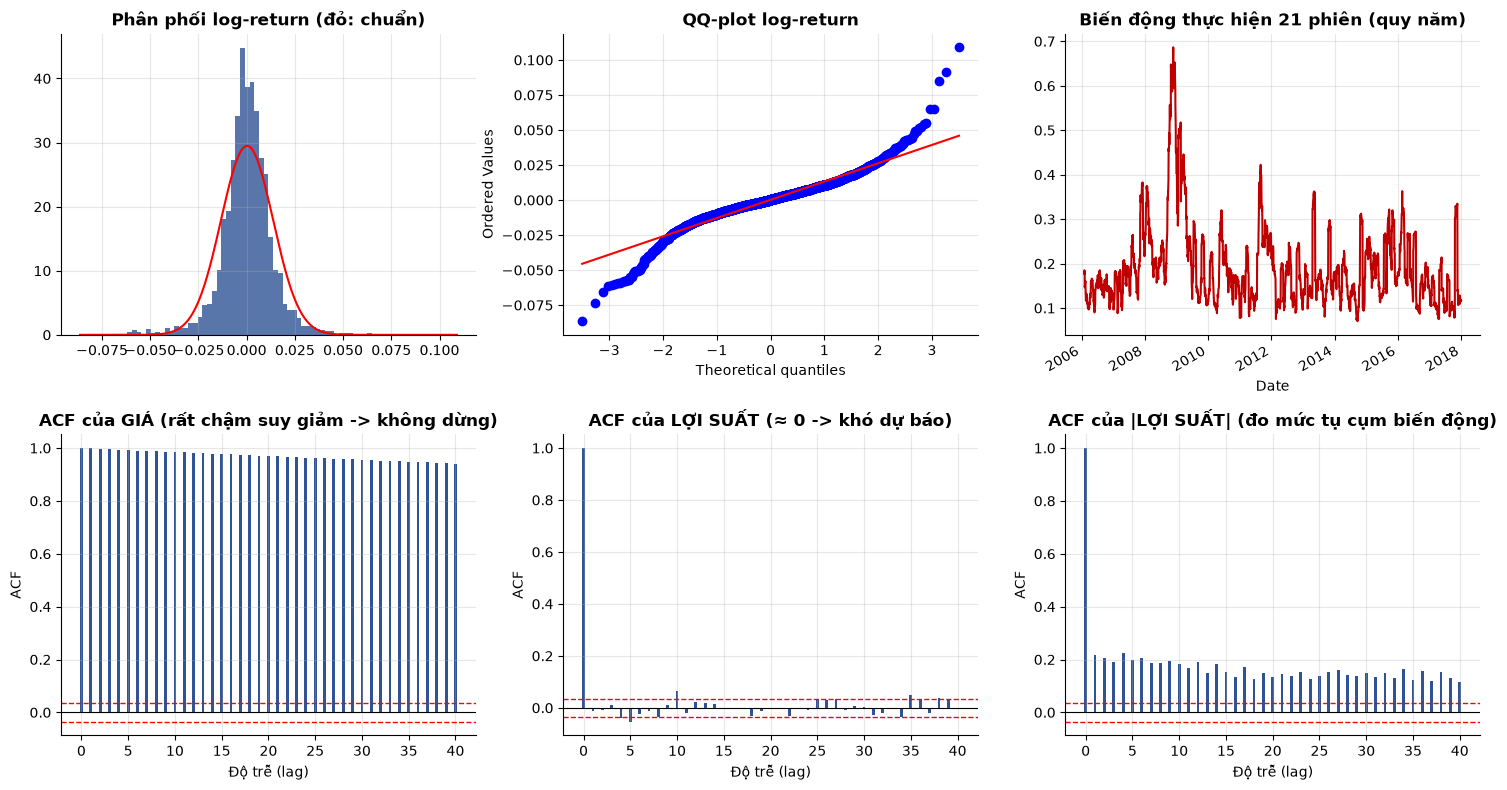

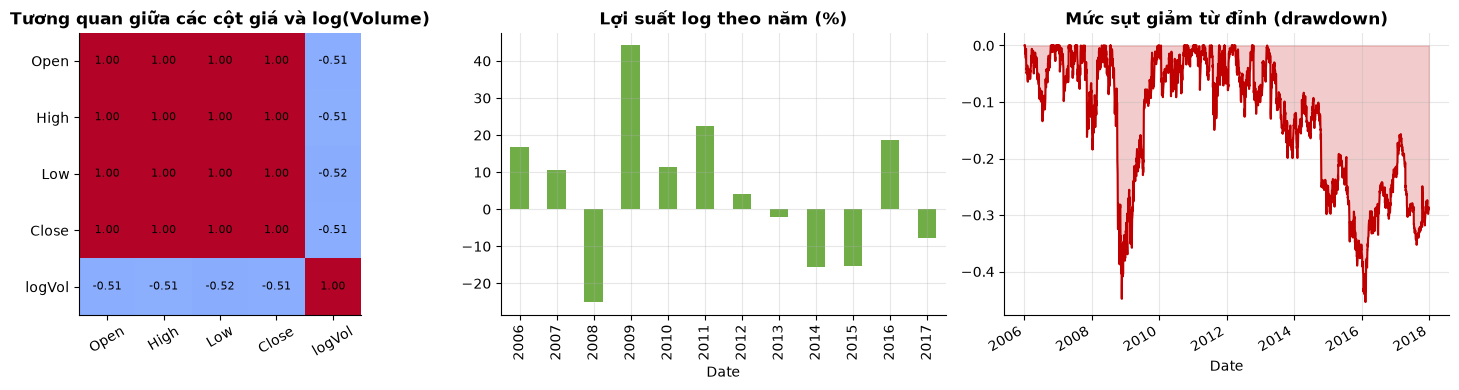

In [7]:
from scipy import stats
ret = np.log(df_t["Close"]).diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
df_t["Close"].plot(ax=axes[0], lw=1, label="Close")
df_t["Close"].rolling(50).mean().plot(ax=axes[0], lw=1.4, label="MA50")
df_t["Close"].rolling(200).mean().plot(ax=axes[0], lw=1.4, label="MA200")
axes[0].set_title(f"{TICKER} – Giá đóng cửa và đường trung bình động"); axes[0].legend()
(df_t["Volume"] / 1e6).plot(ax=axes[1], lw=0.6, c="#7F7F7F"); axes[1].set_title("Khối lượng giao dịch (triệu)")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
# 1) phân phối lợi suất so với phân phối chuẩn
axes[0, 0].hist(ret, bins=80, density=True, color="#2F5496", alpha=0.8)
xs = np.linspace(ret.min(), ret.max(), 300); axes[0, 0].plot(xs, stats.norm.pdf(xs, ret.mean(), ret.std()), "r")
axes[0, 0].set_title("Phân phối log-return (đỏ: chuẩn)")
# 2) QQ-plot
stats.probplot(ret, dist="norm", plot=axes[0, 1]); axes[0, 1].set_title("QQ-plot log-return")
# 3) biến động
(ret.rolling(21).std() * np.sqrt(252)).plot(ax=axes[0, 2], c="#C00000"); axes[0, 2].set_title("Biến động thực hiện 21 phiên (quy năm)")
# 4) ACF giá, lợi suất, |lợi suất|
plot_acf(axes[1, 0], df_t["Close"], 40, "ACF của GIÁ (rất chậm suy giảm -> không dừng)")
plot_acf(axes[1, 1], ret, 40, "ACF của LỢI SUẤT (≈ 0 -> khó dự báo)")
plot_acf(axes[1, 2], ret.abs(), 40, "ACF của |LỢI SUẤT| (đo mức tụ cụm biến động)")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cm = df_t.assign(logVol=np.log1p(df_t["Volume"])).drop(columns="Volume").corr()
im = axes[0].imshow(cm, cmap="coolwarm", vmin=-1, vmax=1); axes[0].grid(False)
axes[0].set_xticks(range(len(cm))); axes[0].set_xticklabels(cm.columns, rotation=30); axes[0].set_yticks(range(len(cm))); axes[0].set_yticklabels(cm.columns)
for i in range(len(cm)):
    for j in range(len(cm)): axes[0].text(j, i, f"{cm.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
axes[0].set_title("Tương quan giữa các cột giá và log(Volume)")
(ret.groupby(ret.index.year).sum() * 100).plot.bar(ax=axes[1], color="#70AD47"); axes[1].set_title("Lợi suất log theo năm (%)")
dd = df_t["Close"] / df_t["Close"].cummax() - 1
dd.plot(ax=axes[2], c="#C00000"); axes[2].fill_between(dd.index, dd.values, 0, color="#C00000", alpha=0.2); axes[2].set_title("Mức sụt giảm từ đỉnh (drawdown)")
plt.tight_layout(); plt.show()

### 2.3 Nhận định tự động về tính chất thống kê

In [8]:
a_p = acf(df_t["Close"], 20); a_r = acf(ret, 20); a_v = acf(ret.abs(), 20)
conf = 1.96 / np.sqrt(len(ret))
print(f"- Lợi suất hằng ngày: TB = {ret.mean() * 100:.3f}%, độ lệch chuẩn = {ret.std() * 100:.2f}%, "
      f"skew = {stats.skew(ret):.2f}, kurtosis dư = {stats.kurtosis(ret):.1f}  (kurtosis dư > 0: đuôi dày hơn phân phối chuẩn)")
print(f"- ACF của giá ở lag 20 = {a_p[20]:.2f} -> " + ("giá tự tương quan rất mạnh, chuỗi không dừng." if a_p[20] > 0.5 else "tự tương quan của giá không quá mạnh."))
print(f"- ACF của lợi suất: lag-1 = {a_r[1]:.3f}, lag-5 = {a_r[5]:.3f} (ngưỡng ±{conf:.3f}) -> " + ("hầu như không có tín hiệu tuyến tính." if max(abs(a_r[1:6])) < 2 * conf else "có một vài tự tương quan đáng chú ý."))
print(f"- ACF của |lợi suất| ở lag 1 = {a_v[1]:.2f} -> " + ("biến động tụ cụm (giai đoạn dao động mạnh đi liền nhau)." if a_v[1] > conf else "chưa thấy hiện tượng tụ cụm biến động rõ rệt."))
try:
    from statsmodels.tsa.stattools import adfuller
    print(f"- Kiểm định ADF: p-value(giá) = {adfuller(df_t['Close'].dropna())[1]:.3f} | p-value(lợi suất) = {adfuller(ret)[1]:.4f}")
    print("  (p > 0.05: không bác bỏ nghiệm đơn vị -> giá không dừng; lợi suất dừng)")
except Exception:
    print("- (Bỏ qua ADF vì chưa cài statsmodels)")
print("=> Vì vậy ta dự báo LỢI SUẤT (dừng) thay vì giá thô, rồi quy đổi lại thành giá: giá(t+1) = giá(t) × exp(lợi suất dự báo).")

- Lợi suất hằng ngày: TB = 0.021%, độ lệch chuẩn = 1.35%, skew = -0.12, kurtosis dư = 6.1  (kurtosis dư > 0: đuôi dày hơn phân phối chuẩn)
- ACF của giá ở lag 20 = 0.97 -> giá tự tương quan rất mạnh, chuỗi không dừng.
- ACF của lợi suất: lag-1 = -0.011, lag-5 = -0.054 (ngưỡng ±0.036) -> hầu như không có tín hiệu tuyến tính.
- ACF của |lợi suất| ở lag 1 = 0.22 -> biến động tụ cụm (giai đoạn dao động mạnh đi liền nhau).
- (Bỏ qua ADF vì chưa cài statsmodels)
=> Vì vậy ta dự báo LỢI SUẤT (dừng) thay vì giá thô, rồi quy đổi lại thành giá: giá(t+1) = giá(t) × exp(lợi suất dự báo).


## 3. Tạo đặc trưng, chia dữ liệu theo thời gian, chuẩn hóa và tạo cửa sổ
Bảy đặc trưng đều **dừng** (không phụ thuộc mức giá tuyệt đối): lợi suất, khoảng nhảy mở cửa, biên độ trong phiên, khối lượng tương đối, độ lệch so với MA5 và MA20, biến động 10 phiên. Nhãn là lợi suất phiên kế tiếp. Các bộ chuẩn hóa chỉ fit trên tập huấn luyện. Mỗi mẫu có dạng `(WINDOW, 7)`.

,ret,gap,range,vol_z,ma5,ma20,vol10,Close,target
Date,,,,,,,,,
2017-12-27,0.0020,0.0008,0.0037,-0.7202,0.0036,-0.0052,0.0078,153.1300,0.0059
2017-12-28,0.0059,0.0005,0.0060,-0.4647,0.0081,0.0006,0.0058,154.0400,-0.0040
2017-12-29,-0.0040,0.0008,0.0085,-0.2177,0.0015,-0.0033,0.0060,153.4200,NaN


Train: (2041, 60, 7) | Val: (450, 60, 7) | Test: (450, 60, 7)
Train: 2006-04-27 -> 2014-06-05 | Val: 2014-06-06 -> 2016-03-18 | Test: 2016-03-21 -> 2017-12-29


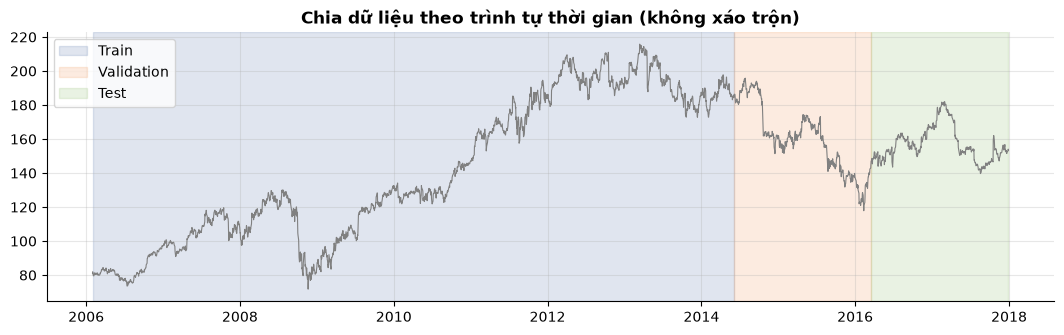

In [9]:
FEATS = ["ret", "gap", "range", "vol_z", "ma5", "ma20", "vol10"]
N_FEATURES, OUT_DIM = len(FEATS), 1

def make_features(d):
    """Tạo đặc trưng dừng từ OHLCV. Dùng lại được cho dự báo đệ quy ở phần 9."""
    o, h, l, c, v = d["Open"], d["High"], d["Low"], d["Close"], d["Volume"]
    prev_c, lv = c.shift(1), np.log1p(v)
    f = pd.DataFrame(index=d.index)
    f["ret"]   = np.log(c / prev_c)                       # lợi suất log hôm nay
    f["gap"]   = np.log(o / prev_c)                       # khoảng nhảy giá lúc mở cửa
    f["range"] = (h - l) / c                              # biên độ trong phiên
    f["vol_z"] = lv - lv.rolling(20).mean()               # khối lượng so với TB 20 phiên (log)
    f["ma5"]   = c / c.rolling(5).mean() - 1              # lệch so với MA5
    f["ma20"]  = c / c.rolling(20).mean() - 1             # lệch so với MA20
    f["vol10"] = f["ret"].rolling(10).std()               # biến động 10 phiên
    f["Close"] = c
    return f.replace([np.inf, -np.inf], np.nan)

feat = make_features(df_t)
feat["target"] = feat["ret"].shift(-1)                    # NHÃN: lợi suất của phiên kế tiếp
feat = feat.dropna(subset=FEATS)                          # hàng cuối có target=NaN được giữ lại cho dự báo thật
display(feat.tail(3))

F = feat[FEATS].values.astype("float32")
T = feat["target"].values
C = feat["Close"].values
idx = feat.index
n = len(feat); n_lab = n - 1                              # số hàng có nhãn
i1, i2 = int(n_lab * TRAIN_RATIO), int(n_lab * (TRAIN_RATIO + VAL_RATIO))

scaler_x = StandardScaler().fit(F[:i1])
scaler_y = StandardScaler().fit(T[:i1].reshape(-1, 1))
F_s = scaler_x.transform(F).astype("float32")

end_idx = np.arange(WINDOW - 1, n_lab)                    # chỉ số phiên cuối của mỗi cửa sổ
X_all = np.stack([F_s[t - WINDOW + 1:t + 1] for t in end_idx]).astype("float32")
y_all = scaler_y.transform(T[end_idx].reshape(-1, 1)).astype("float32")
m_tr, m_va, m_te = end_idx < i1, (end_idx >= i1) & (end_idx < i2), end_idx >= i2
X_train, y_train = X_all[m_tr], y_all[m_tr]
X_val,   y_val   = X_all[m_va], y_all[m_va]
X_test,  y_test  = X_all[m_te], y_all[m_te]

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Train: {idx[WINDOW]:%Y-%m-%d} -> {idx[i1]:%Y-%m-%d} | Val: {idx[i1 + 1]:%Y-%m-%d} -> {idx[i2]:%Y-%m-%d} | Test: {idx[i2 + 1]:%Y-%m-%d} -> {idx[-1]:%Y-%m-%d}")

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(idx, C, lw=0.8, c="gray")
for lo, hi, c_, lb in [(0, i1, "#2F5496", "Train"), (i1, i2, "#ED7D31", "Validation"), (i2, n, "#70AD47", "Test")]:
    ax.axvspan(idx[lo], idx[hi - 1], color=c_, alpha=0.15, label=lb)
ax.set_title("Chia dữ liệu theo trình tự thời gian (không xáo trộn)"); ax.legend(); plt.show()

## 4. Mô hình cơ sở (baseline)
*Naive* dự báo lợi suất = 0 (giá ngày mai = giá hôm nay) và *Drift* dự báo bằng lợi suất trung bình của tập train. Với dữ liệu này, baseline Naive rất khó đánh bại.

In [10]:
def eval_split(mask, ret_hat):
    """Quy đổi lợi suất dự báo -> giá và tính các chỉ số."""
    t = end_idx[mask]
    close_t, ret_true = C[t], T[t]
    p_true, p_hat = close_t * np.exp(ret_true), close_t * np.exp(ret_hat)
    sse, sse0 = np.sum((ret_true - ret_hat) ** 2), np.sum(ret_true ** 2)
    nz = np.any(ret_hat != 0)
    return {
        "RMSE giá": float(np.sqrt(np.mean((p_true - p_hat) ** 2))),
        "MAE giá": float(np.mean(np.abs(p_true - p_hat))),
        "MAPE giá (%)": float(np.mean(np.abs((p_true - p_hat) / p_true)) * 100),
        "RMSE lợi suất": float(np.sqrt(sse / len(t))),
        "R² so với dự báo 0": float(1 - sse / sse0),
        "Đúng hướng (%)": float(np.mean(np.sign(ret_hat) == np.sign(ret_true)) * 100) if nz else np.nan,
    }

masks = {"val": m_va, "test": m_te}
ret_true = {k: T[end_idx[m]] for k, m in masks.items()}
drift = float(T[:i1].mean())                               # lợi suất trung bình của tập train
ret_hats = {k: {"Naive (giá hôm nay)": np.zeros(m.sum()), "Drift (TB train)": np.full(m.sum(), drift)} for k, m in masks.items()}

up_rate = float(np.mean(ret_true["test"] > 0) * 100)
print(f"Tỷ lệ phiên tăng giá trong tập test: {up_rate:.1f}%  (mốc so sánh cho độ chính xác hướng: luôn đoán 'tăng' đạt ≈ {up_rate:.1f}%)")
display(pd.DataFrame({k: eval_split(masks["test"], v) for k, v in ret_hats["test"].items()}).T)

Tỷ lệ phiên tăng giá trong tập test: 51.3%  (mốc so sánh cho độ chính xác hướng: luôn đoán 'tăng' đạt ≈ 51.3%)


,RMSE giá,MAE giá,MAPE giá (%),RMSE lợi suất,R² so với dự báo 0,Đúng hướng (%)
Naive (giá hôm nay),1.6180,1.0723,0.6870,0.0104,0.0000,NaN
Drift (TB train),1.6190,1.0723,0.6870,0.0104,-0.0008,51.3333


## 5. Xây dựng và huấn luyện RNN / LSTM / GRU (Keras (TensorFlow))
Ba kiến trúc dùng cùng siêu tham số để so sánh công bằng.

In [11]:
def build_model(kind, input_shape, out_dim):
    """2 lớp RNN/LSTM/GRU xếp chồng + Dropout + đầu ra Dense."""
    Cell = {"RNN": layers.SimpleRNN, "LSTM": layers.LSTM, "GRU": layers.GRU}[kind]
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        Cell(UNITS, return_sequences=True),
        layers.Dropout(DROPOUT),
        Cell(UNITS),
        layers.Dropout(DROPOUT),
        layers.Dense(32, activation="relu"),
        layers.Dense(out_dim),
    ], name=kind)
    model.compile(optimizer=keras.optimizers.Adam(LR), loss="mse")
    return model

def train_model(kind, X_tr, y_tr, X_va, y_va):
    keras.utils.set_random_seed(SEED)
    model = build_model(kind, X_tr.shape[1:], y_tr.shape[1])
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=max(3, PATIENCE // 3), min_lr=1e-5),
    ]
    h = model.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=EPOCHS,
                  batch_size=BATCH_SIZE, callbacks=callbacks, verbose=1)
    n_ep = len(h.history["loss"])
    print(f"{kind:5s} | dừng sau {n_ep:3d} epoch | val_loss tốt nhất = {min(h.history['val_loss']):.4f} "
          f"| số tham số = {model.count_params():,}")
    return model, {"loss": h.history["loss"], "val_loss": h.history["val_loss"]}

def predict_scaled(model, X):
    """Dự đoán trên không gian đã chuẩn hóa, trả về mảng (n_mẫu, out_dim)."""
    return model.predict(X, batch_size=256, verbose=1).reshape(len(X), -1)

# Xem cấu trúc một mô hình mẫu
build_model("LSTM", (WINDOW, N_FEATURES), OUT_DIM).summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          18,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 53,569 (209.25 KB)

 Trainable params: 53,569 (209.25 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
KINDS = ["RNN", "LSTM", "GRU"]
models, histories = {}, {}
for kind in KINDS:
    models[kind], histories[kind] = train_model(kind, X_train, y_train, X_val, y_val)

Epoch 1/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 1.1412 - val_loss: 0.8961 - learning_rate: 0.0010
Epoch 2/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.0757 - val_loss: 0.9088 - learning_rate: 0.0010
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.0252 - val_loss: 0.8939 - learning_rate: 0.0010
Epoch 4/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.0199 - val_loss: 0.9058 - learning_rate: 0.0010
Epoch 5/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.9909 - val_loss: 0.9003 - learning_rate: 0.0010
Epoch 6/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.9690 - val_loss: 0.9369 - learning_rate: 0.0010
Epoch 7/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.9514 - val_loss: 0.9518 - learning_rate: 0.0010
Epoch 8/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.9150 - val_loss: 0.9265 - learning_rate: 5.0000e-04
Epoch 9/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.8878 - val_loss: 0.9487 - learning_rate: 5.0000e-04
Ep

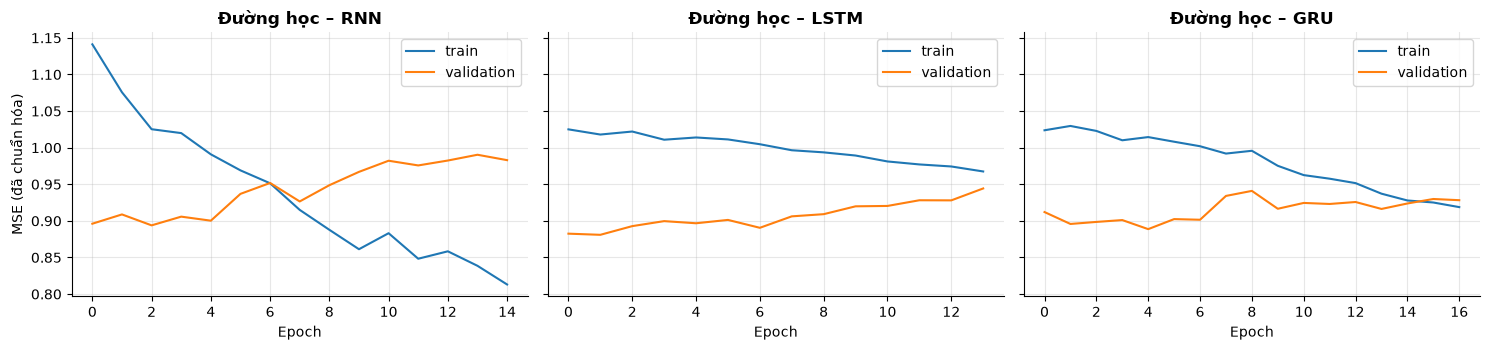

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), sharey=True)
for ax, kind in zip(axes, KINDS):
    ax.plot(histories[kind]["loss"], label="train"); ax.plot(histories[kind]["val_loss"], label="validation")
    ax.set_title(f"Đường học – {kind}"); ax.set_xlabel("Epoch"); ax.legend()
axes[0].set_ylabel("MSE (đã chuẩn hóa)")
plt.tight_layout(); plt.show()

## 6. Đánh giá và trực quan hóa dự đoán
Các chỉ số được tính ở cả mức **giá** (dễ đọc, nhưng bị lạc quan giả tạo do tự tương quan) và mức **lợi suất** (phản ánh khả năng dự báo thật), cùng độ chính xác dự đoán hướng.

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 364ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 429ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/stepWARNING:tensorflow:6 out of the last 10 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001F7D35BE980> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 408ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


,RMSE giá,MAE giá,MAPE giá (%),RMSE lợi suất,R² so với dự báo 0,Đúng hướng (%)
Naive (giá hôm nay),1.6180,1.0723,0.6870,0.0104,0.0000,NaN
Drift (TB train),1.6190,1.0723,0.6870,0.0104,-0.0008,51.3333
GRU,1.6354,1.0912,0.6993,0.0105,-0.0215,49.7778
LSTM,1.6368,1.0866,0.6961,0.0105,-0.0219,48.6667
RNN,1.6742,1.1316,0.7246,0.0108,-0.0670,49.5556


Mô hình tốt nhất trên tập kiểm định (theo RMSE lợi suất): LSTM


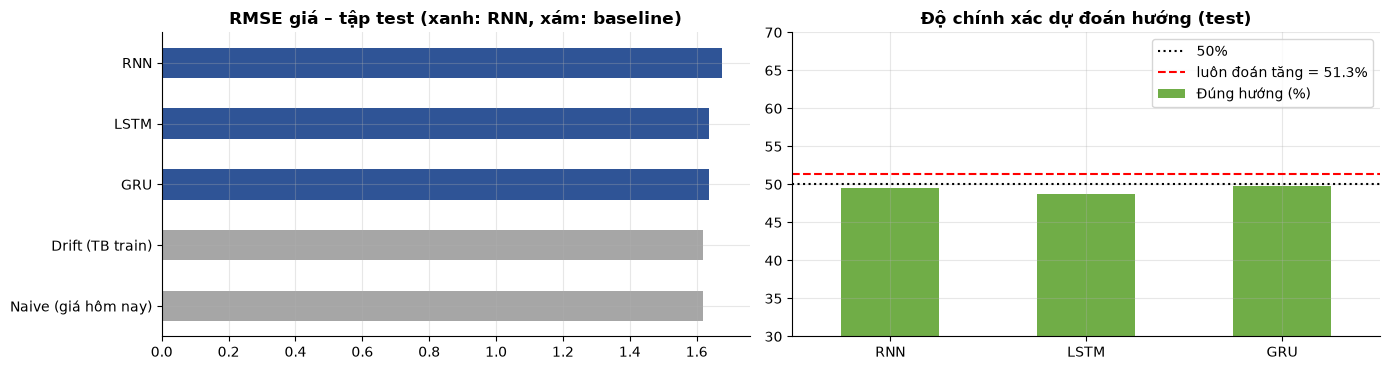

In [14]:
inv_y = lambda z: scaler_y.inverse_transform(np.asarray(z).reshape(-1, 1)).ravel()
for kind in KINDS:
    for k, X in [("val", X_val), ("test", X_test)]:
        ret_hats[k][kind] = inv_y(predict_scaled(models[kind], X)[:, 0])

tab = {name: {**{f"{m} (val)": v for m, v in eval_split(masks["val"], ret_hats["val"][name]).items() if m in ["RMSE lợi suất"]},
              **eval_split(masks["test"], ret_hats["test"][name])} for name in ret_hats["test"]}
results = pd.DataFrame(tab).T
display(results[["RMSE giá", "MAE giá", "MAPE giá (%)", "RMSE lợi suất", "R² so với dự báo 0", "Đúng hướng (%)"]].sort_values("RMSE giá"))

best_kind = min(KINDS, key=lambda k: results.loc[k, "RMSE lợi suất (val)"])
print(f"Mô hình tốt nhất trên tập kiểm định (theo RMSE lợi suất): {best_kind}")

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
s = results["RMSE giá"].sort_values()
s.plot.barh(ax=axes[0], color=["#2F5496" if i in KINDS else "#A6A6A6" for i in s.index]); axes[0].set_title("RMSE giá – tập test (xanh: RNN, xám: baseline)")
d = results.loc[KINDS, "Đúng hướng (%)"]
d.plot.bar(ax=axes[1], color="#70AD47"); axes[1].axhline(50, c="k", ls=":", label="50%"); axes[1].axhline(up_rate, c="r", ls="--", label=f"luôn đoán tăng = {up_rate:.1f}%")
axes[1].set_ylim(30, 70); axes[1].set_title("Độ chính xác dự đoán hướng (test)"); axes[1].legend(); axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

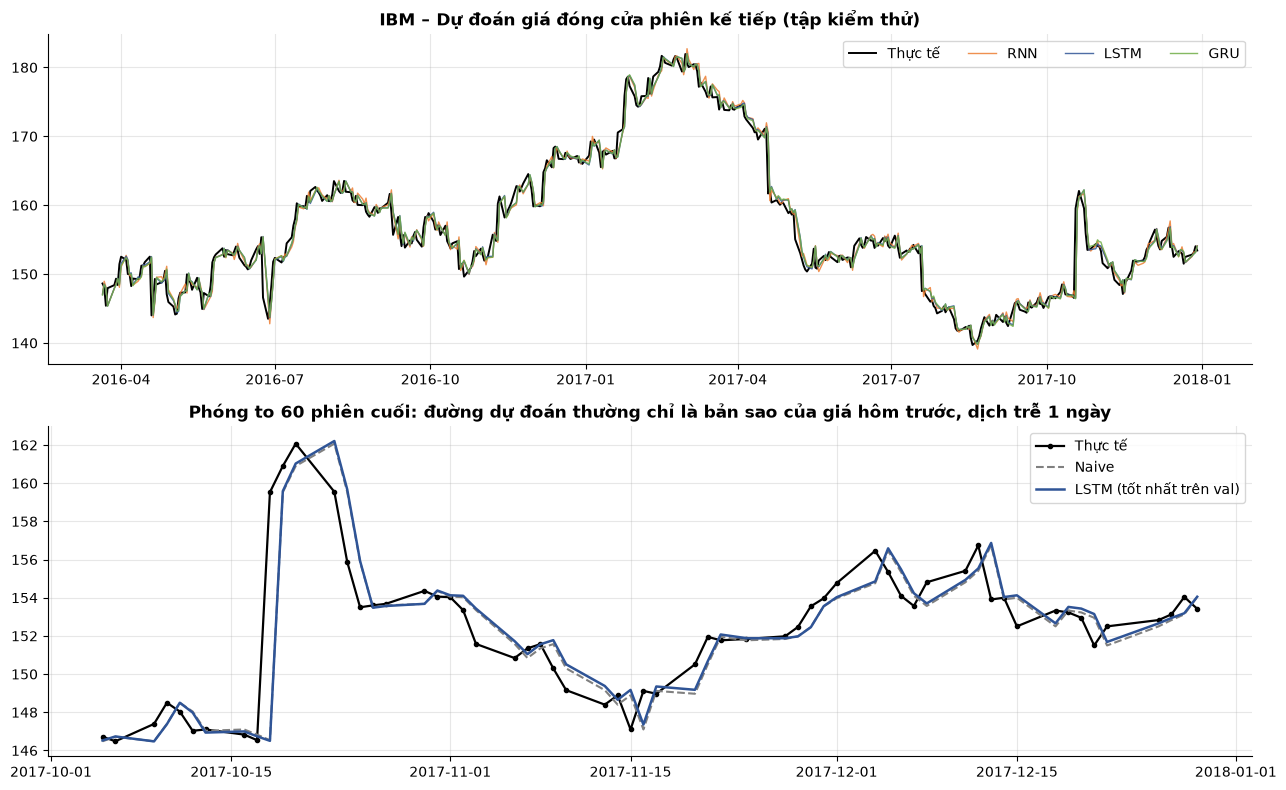

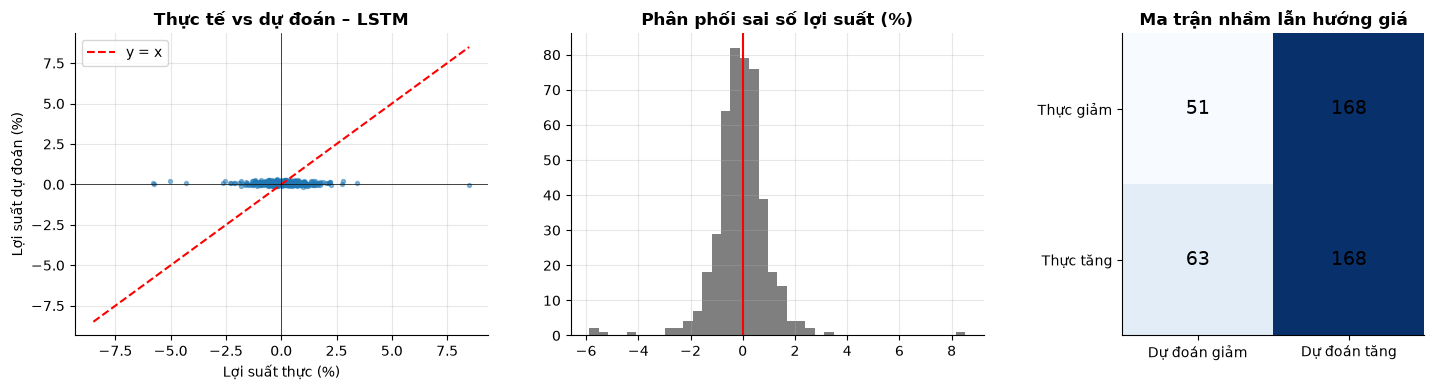

Độ lệch chuẩn lợi suất thực = 1.04% | dự đoán = 0.091%  (dự đoán co cụm quanh 0 nghĩa là mô hình rất thận trọng, đúng với bản chất nhiễu của lợi suất)


In [15]:
t_te = end_idx[m_te]
d_te = idx[t_te + 1]                                   # ngày của giá được dự đoán
price_true = C[t_te + 1]
price_hat = {k: C[t_te] * np.exp(ret_hats["test"][k]) for k in ret_hats["test"]}
colors = {"RNN": "#ED7D31", "LSTM": "#2F5496", "GRU": "#70AD47"}

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
axes[0].plot(d_te, price_true, c="k", lw=1.4, label="Thực tế")
for k in KINDS: axes[0].plot(d_te, price_hat[k], c=colors[k], lw=1, alpha=0.85, label=k)
axes[0].set_title(f"{TICKER} – Dự đoán giá đóng cửa phiên kế tiếp (tập kiểm thử)"); axes[0].legend(ncol=4)
z = slice(-60, None)
axes[1].plot(d_te[z], price_true[z], c="k", lw=1.6, marker="o", ms=3, label="Thực tế")
axes[1].plot(d_te[z], price_hat["Naive (giá hôm nay)"][z], c="gray", ls="--", label="Naive")
axes[1].plot(d_te[z], price_hat[best_kind][z], c=colors[best_kind], lw=1.8, label=f"{best_kind} (tốt nhất trên val)")
axes[1].set_title("Phóng to 60 phiên cuối: đường dự đoán thường chỉ là bản sao của giá hôm trước, dịch trễ 1 ngày"); axes[1].legend()
plt.tight_layout(); plt.show()

# --- Phân tích ở mức lợi suất (nơi thật sự đo được khả năng dự báo) ---
rt, rh = ret_true["test"], ret_hats["test"][best_kind]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(rt * 100, rh * 100, s=8, alpha=0.5); lim = max(abs(rt).max(), abs(rh).max()) * 100
axes[0].plot([-lim, lim], [-lim, lim], "r--", label="y = x"); axes[0].axhline(0, c="k", lw=0.5); axes[0].axvline(0, c="k", lw=0.5)
axes[0].set_xlabel("Lợi suất thực (%)"); axes[0].set_ylabel("Lợi suất dự đoán (%)"); axes[0].set_title(f"Thực tế vs dự đoán – {best_kind}"); axes[0].legend()
axes[1].hist((rt - rh) * 100, bins=40, color="#7F7F7F"); axes[1].axvline(0, c="r"); axes[1].set_title("Phân phối sai số lợi suất (%)")
cmx = pd.crosstab(np.sign(rt) > 0, np.sign(rh) > 0).reindex(index=[False, True], columns=[False, True], fill_value=0)
axes[2].imshow(cmx.values, cmap="Blues"); axes[2].grid(False)
axes[2].set_xticks([0, 1]); axes[2].set_xticklabels(["Dự đoán giảm", "Dự đoán tăng"]); axes[2].set_yticks([0, 1]); axes[2].set_yticklabels(["Thực giảm", "Thực tăng"])
for i in range(2):
    for j in range(2): axes[2].text(j, i, int(cmx.values[i, j]), ha="center", va="center", fontsize=14)
axes[2].set_title("Ma trận nhầm lẫn hướng giá")
plt.tight_layout(); plt.show()
print(f"Độ lệch chuẩn lợi suất thực = {rt.std() * 100:.2f}% | dự đoán = {rh.std() * 100:.3f}%  "
      "(dự đoán co cụm quanh 0 nghĩa là mô hình rất thận trọng, đúng với bản chất nhiễu của lợi suất)")

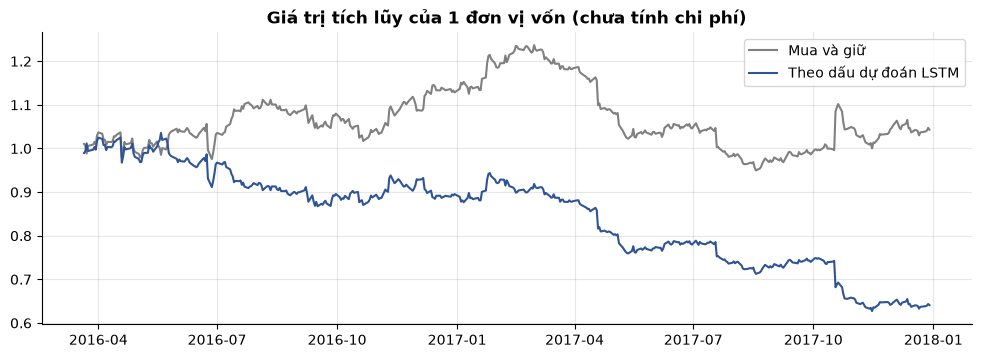

Sharpe (quy năm) chiến lược: -1.51 | mua-giữ: 0.14
Chỉ mang tính minh họa: kết quả không đủ để kết luận về khả năng sinh lời thực tế.


In [16]:
# ---- Minh họa: chiến lược mua/bán khống theo dấu dự đoán so với mua và giữ (KHÔNG tính phí giao dịch) ----
pos_ = np.sign(ret_hats["test"][best_kind])
strat = pos_ * ret_true["test"]
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(d_te, np.exp(np.cumsum(ret_true["test"])), label="Mua và giữ", c="gray")
ax.plot(d_te, np.exp(np.cumsum(strat)), label=f"Theo dấu dự đoán {best_kind}", c=colors[best_kind])
ax.set_title("Giá trị tích lũy của 1 đơn vị vốn (chưa tính chi phí)"); ax.legend(); plt.show()
print(f"Sharpe (quy năm) chiến lược: {strat.mean() / (strat.std() + 1e-12) * np.sqrt(252):.2f} | mua-giữ: {ret_true['test'].mean() / ret_true['test'].std() * np.sqrt(252):.2f}")
print("Chỉ mang tính minh họa: kết quả không đủ để kết luận về khả năng sinh lời thực tế.")

## 7. Phân tích đặc trưng nào quan trọng

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
2/2 ━━━━━

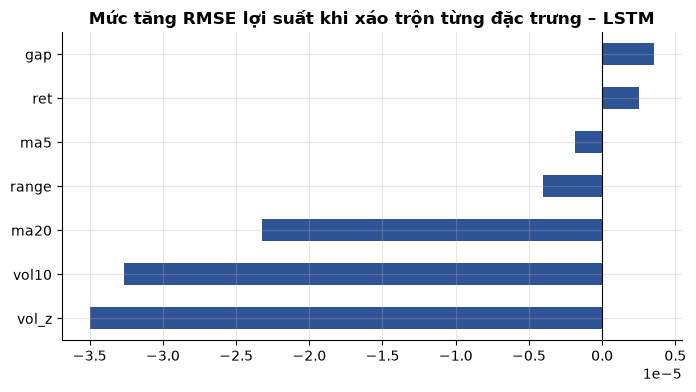

Đặc trưng mô hình dựa vào nhiều nhất: gap


In [17]:
base = eval_split(masks["test"], ret_hats["test"][best_kind])["RMSE lợi suất"]
rng = np.random.default_rng(SEED)
imp = {}
for j, name in enumerate(FEATS):
    ds = []
    for _ in range(5):
        Xp = X_test.copy(); Xp[:, :, j] = Xp[rng.permutation(len(Xp))][:, :, j]
        ds.append(eval_split(masks["test"], inv_y(predict_scaled(models[best_kind], Xp)[:, 0]))["RMSE lợi suất"] - base)
    imp[name] = np.mean(ds)
imp = pd.Series(imp).sort_values()
fig, ax = plt.subplots(figsize=(8, 4)); imp.plot.barh(ax=ax, color="#2F5496"); ax.axvline(0, c="k", lw=0.8)
ax.set_title(f"Mức tăng RMSE lợi suất khi xáo trộn từng đặc trưng – {best_kind}"); plt.show()
print("Đặc trưng mô hình dựa vào nhiều nhất:", imp.idxmax())

## 8. Dự báo tương lai
Dự báo đệ quy `HORIZON` phiên sau phiên cuối cùng của dữ liệu.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


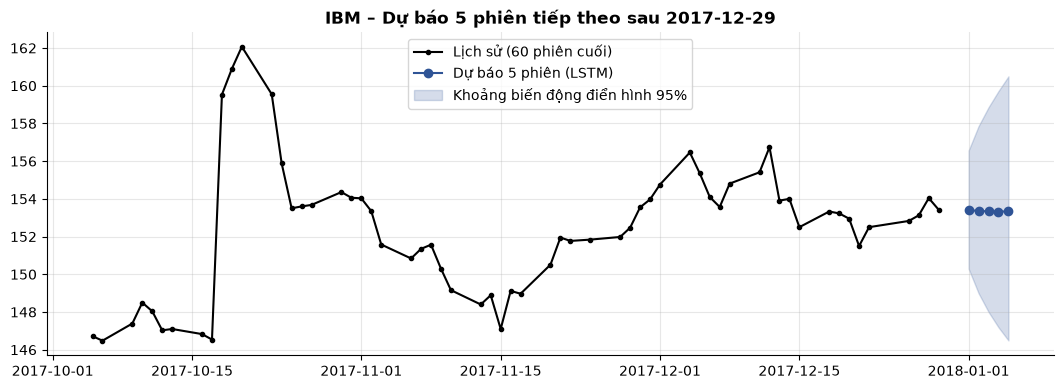

,Giá dự báo,Lợi suất dự báo,Cận dưới (95%),Cận trên (95%)
Ngày,,,,
2018-01-01,153.3980,-0.0000,150.2980,156.5610
2018-01-02,153.3640,-0.0000,149.0000,157.8560
2018-01-03,153.3360,-0.0000,148.0090,158.8550
2018-01-04,153.3250,-0.0000,147.1910,159.7140
2018-01-05,153.3360,0.0000,146.4940,160.4970


Khoảng 95% được dựng từ độ biến động lịch sử của lợi suất, phản ánh mức bất định thực tế lớn hơn nhiều so với độ dịch chuyển của đường dự báo.


In [18]:
def forecast_future(model, horizon):
    """Dự báo đệ quy: giá dự báo được thêm vào lịch sử như một phiên mới (O=H=L=C, Volume giữ nguyên), rồi tính lại đặc trưng."""
    hist = df_t[["Open", "High", "Low", "Close", "Volume"]].tail(WINDOW + 60).copy()
    rows = []
    for h in range(1, horizon + 1):
        f = make_features(hist)[FEATS].dropna().tail(WINDOW)
        x = scaler_x.transform(f.values).astype("float32")[None, ...]
        r = float(inv_y(predict_scaled(model, x)[:, 0])[0])
        new_close = hist["Close"].iloc[-1] * np.exp(r)
        d = hist.index[-1] + pd.offsets.BDay(1)
        hist.loc[d] = [new_close, new_close, new_close, new_close, hist["Volume"].iloc[-1]]
        rows.append((d, new_close, r))
    return pd.DataFrame(rows, columns=["Ngày", "Giá dự báo", "Lợi suất dự báo"]).set_index("Ngày")

fc = forecast_future(models[best_kind], HORIZON)
s_ret = float(ret_true["test"].std())
steps = np.arange(1, HORIZON + 1)
fc["Cận dưới (95%)"] = df_t["Close"].iloc[-1] * np.exp(np.cumsum(fc["Lợi suất dự báo"].values) - 1.96 * s_ret * np.sqrt(steps))
fc["Cận trên (95%)"] = df_t["Close"].iloc[-1] * np.exp(np.cumsum(fc["Lợi suất dự báo"].values) + 1.96 * s_ret * np.sqrt(steps))

h_ = df_t["Close"].iloc[-60:]
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.plot(h_.index, h_.values, c="k", marker="o", ms=3, label="Lịch sử (60 phiên cuối)")
ax.plot(fc.index, fc["Giá dự báo"], c=colors[best_kind], marker="o", label=f"Dự báo {HORIZON} phiên ({best_kind})")
ax.fill_between(fc.index, fc["Cận dưới (95%)"], fc["Cận trên (95%)"], color=colors[best_kind], alpha=0.2, label="Khoảng biến động điển hình 95%")
ax.set_title(f"{TICKER} – Dự báo {HORIZON} phiên tiếp theo sau {df_t.index[-1]:%Y-%m-%d}"); ax.legend(); plt.show()
display(fc.round(3))
print("Khoảng 95% được dựng từ độ biến động lịch sử của lợi suất, phản ánh mức bất định thực tế lớn hơn nhiều so với độ dịch chuyển của đường dự báo.")

## 9. Kết luận

In [19]:
r = results
b = r.loc[best_kind]; n0 = r.loc["Naive (giá hôm nay)"]
print(f"RMSE giá test – {best_kind}: {b['RMSE giá']:.3f} | Naive: {n0['RMSE giá']:.3f} | thay đổi so với Naive: {(1 - b['RMSE giá'] / n0['RMSE giá']) * 100:+.2f}%")
print(f"R² so với dự báo 0 (lợi suất): {b['R² so với dự báo 0']:.4f} | Đúng hướng: {b['Đúng hướng (%)']:.1f}% (mốc 'luôn đoán tăng' = {up_rate:.1f}%)")
if b["R² so với dự báo 0"] > 0.01 and b["Đúng hướng (%)"] > up_rate + 2:
    print("=> Có bằng chứng (yếu) cho thấy mô hình bắt được chút tín hiệu; cần kiểm chứng thêm qua nhiều mã và nhiều giai đoạn.")
else:
    print("=> Mô hình không vượt rõ rệt dự báo 'giá không đổi'. Đồ thị giá khớp chủ yếu nhờ giá hôm nay đã chứa gần hết thông tin, "
          "phù hợp với tính chất gần-ngẫu-nhiên của giá cổ phiếu.")

RMSE giá test – LSTM: 1.637 | Naive: 1.618 | thay đổi so với Naive: -1.16%
R² so với dự báo 0 (lợi suất): -0.0219 | Đúng hướng: 48.7% (mốc 'luôn đoán tăng' = 51.3%)
=> Mô hình không vượt rõ rệt dự báo 'giá không đổi'. Đồ thị giá khớp chủ yếu nhờ giá hôm nay đã chứa gần hết thông tin, phù hợp với tính chất gần-ngẫu-nhiên của giá cổ phiếu.


### Cách đọc kết quả
- **Đường giá dự đoán khớp thực tế ≠ mô hình dự báo tốt.** Vì giá hôm nay ≈ giá ngày mai, mọi mô hình đều cho đường "khớp". Thước đo đáng tin là RMSE lợi suất, R² so với dự báo 0 và độ chính xác hướng so với mốc `luôn đoán tăng`.
- **RNN vs LSTM vs GRU:** khác biệt thường nhỏ và thay đổi theo hạt giống ngẫu nhiên; nên lặp lại nhiều seed và nhiều mã để kết luận.
- **Hạn chế:** chỉ một mã, một cách chia thời gian; giai đoạn test có xu hướng tăng mạnh; chưa tính chi phí giao dịch.
- **Hướng mở rộng:** huấn luyện chung 30 mã, thêm chỉ báo kỹ thuật/dữ liệu vĩ mô, walk-forward validation, dự báo biến động (volatility) vốn dễ dự báo hơn lợi suất.